# Data Analysis

This analysis explores the overall patterns and characteristics of the datasets. It highlights class distribution, object density, and differences between Pure Culture and Clinical Specimen data.


## Dataset Sources

- `Pure Culture`: regrouped from the public dataset [Bacteria Data for Machine Vision and Digital Biology](https://data.mendeley.com/datasets/cvkgfzp7ck/1)
- `Clinical Specimen`: derived from [Clinical Bacteria DataSet](https://zenodo.org/records/10526360)

In [1]:
from pathlib import Path
from collections import Counter
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image

plt.style.use("default")
random.seed(42)
np.random.seed(42)

PROJECT_ROOT = Path.cwd()
PURE_ROOT = PROJECT_ROOT / "Data" / "Pure Culture"
CLINICAL_ROOT = PROJECT_ROOT / "Data" / "Clinical Specimen"

PURE_IMAGES_DIR = PURE_ROOT / "images"
PURE_LABELS_DIR = PURE_ROOT / "labels"
CLINICAL_IMAGES_DIR = CLINICAL_ROOT / "images"
CLINICAL_LABELS_DIR = CLINICAL_ROOT / "labels"

CLASS_ID_TO_NAME = {
    0: "Gram-negative cocci",
    1: "Gram-positive cocci",
    2: "Gram-negative bacilli",
    3: "Gram-positive bacilli",
}

PURE_PREFIX_TO_CLASS_ID = {
    "negative_cocci": 0,
    "positive_cocci": 1,
    "negative_bacilli": 2,
    "positive_bacilli": 3,
}

CLASS_COLORS = {
    0: "tab:blue",
    1: "tab:red",
    2: "tab:green",
    3: "tab:orange",
}

PURE_ROOT, CLINICAL_ROOT

Matplotlib is building the font cache; this may take a moment.


(WindowsPath('d:/Senior/gram-stain-bacteria-detection/Data/Pure Culture'),
 WindowsPath('d:/Senior/gram-stain-bacteria-detection/Data/Clinical Specimen'))

## Class Definition and Assumptions

Final four classes used in this project:

- `0`: Gram-negative cocci
- `1`: Gram-positive cocci
- `2`: Gram-negative bacilli
- `3`: Gram-positive bacilli

Notebook-specific assumptions:

- `Clinical Specimen` uses the YOLO class IDs directly from label files.
- `Pure Culture` images were flattened into `images/labels` format, but the labels are pseudo-labels.
- For `Pure Culture`, class identity is inferred from the filename prefix created during dataset restructuring, and each bounding box is assigned to that image-level class.

In [2]:
def human_readable_size(num_bytes: int) -> str:
    units = ["B", "KB", "MB", "GB", "TB"]
    value = float(num_bytes)
    for unit in units:
        if value < 1024 or unit == units[-1]:
            return f"{value:.2f} {unit}"
        value /= 1024


def list_image_files(images_dir: Path):
    patterns = ["*.png", "*.jpg", "*.jpeg"]
    files = []
    for pattern in patterns:
        files.extend(images_dir.glob(pattern))
    return sorted(files)


def infer_pure_class_id_from_stem(stem: str) -> int:
    for prefix, class_id in PURE_PREFIX_TO_CLASS_ID.items():
        if stem.startswith(prefix + "__"):
            return class_id
    raise ValueError(f"Could not infer pure culture class from filename: {stem}")


def load_yolo_labels(label_path: Path, forced_class_id: int | None = None):
    records = []
    if not label_path.exists():
        return records

    for line in label_path.read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if not line:
            continue
        parts = line.split()
        if len(parts) != 5:
            continue

        raw_class_id = int(float(parts[0]))
        class_id = forced_class_id if forced_class_id is not None else raw_class_id
        xc, yc, w, h = map(float, parts[1:])
        records.append(
            {
                "raw_class_id": raw_class_id,
                "class_id": class_id,
                "class_name": CLASS_ID_TO_NAME[class_id],
                "x_center_norm": xc,
                "y_center_norm": yc,
                "width_norm": w,
                "height_norm": h,
                "area_norm": w * h,
            }
        )
    return records


def load_dataset(images_dir: Path, labels_dir: Path, dataset_name: str, label_type: str):
    image_rows = []
    box_rows = []

    if not images_dir.exists() or not labels_dir.exists():
        return pd.DataFrame(), pd.DataFrame()

    image_files = list_image_files(images_dir)
    for image_path in image_files:
        stem = image_path.stem
        label_path = labels_dir / f"{stem}.txt"

        with Image.open(image_path) as img:
            width, height = img.size

        forced_class_id = None
        if dataset_name == "Pure Culture":
            forced_class_id = infer_pure_class_id_from_stem(stem)

        boxes = load_yolo_labels(label_path, forced_class_id=forced_class_id)

        image_rows.append(
            {
                "dataset": dataset_name,
                "label_type": label_type,
                "image_stem": stem,
                "image_path": str(image_path),
                "label_path": str(label_path),
                "image_width": width,
                "image_height": height,
                "image_area_px": width * height,
                "image_size_bytes": image_path.stat().st_size,
                "label_exists": label_path.exists(),
                "num_objects": len(boxes),
            }
        )

        for idx, box in enumerate(boxes):
            box_rows.append(
                {
                    "dataset": dataset_name,
                    "label_type": label_type,
                    "image_stem": stem,
                    "image_path": str(image_path),
                    "label_path": str(label_path),
                    "object_index": idx,
                    "class_id": box["class_id"],
                    "raw_class_id": box["raw_class_id"],
                    "class_name": box["class_name"],
                    "x_center_norm": box["x_center_norm"],
                    "y_center_norm": box["y_center_norm"],
                    "width_norm": box["width_norm"],
                    "height_norm": box["height_norm"],
                    "area_norm": box["area_norm"],
                    "image_width": width,
                    "image_height": height,
                    "bbox_width_px": box["width_norm"] * width,
                    "bbox_height_px": box["height_norm"] * height,
                    "bbox_area_px": box["area_norm"] * width * height,
                }
            )

    images_df = pd.DataFrame(image_rows)
    boxes_df = pd.DataFrame(box_rows)
    return images_df, boxes_df


def dataset_summary(images_df: pd.DataFrame, boxes_df: pd.DataFrame) -> pd.DataFrame:
    if images_df.empty:
        return pd.DataFrame()

    summary = (
        images_df.groupby(["dataset", "label_type"], as_index=False)
        .agg(
            images=("image_stem", "count"),
            labels_present=("label_exists", "sum"),
            total_image_bytes=("image_size_bytes", "sum"),
            avg_width_px=("image_width", "mean"),
            avg_height_px=("image_height", "mean"),
        )
    )

    object_counts = boxes_df.groupby("dataset").size().to_dict() if not boxes_df.empty else {}
    summary["objects"] = summary["dataset"].map(object_counts).fillna(0).astype(int)
    summary["classes"] = 4
    summary["dataset_size"] = summary["total_image_bytes"].map(human_readable_size)
    summary["avg_width_px"] = summary["avg_width_px"].round(1)
    summary["avg_height_px"] = summary["avg_height_px"].round(1)
    return summary[["dataset", "label_type", "images", "labels_present", "objects", "classes", "avg_width_px", "avg_height_px", "dataset_size"]]


def class_distribution_table(boxes_df: pd.DataFrame) -> pd.DataFrame:
    if boxes_df.empty:
        return pd.DataFrame()

    counts = (
        boxes_df.groupby(["dataset", "class_id", "class_name"], as_index=False)
        .size()
        .rename(columns={"size": "count"})
    )
    counts["percentage"] = counts.groupby("dataset")["count"].transform(lambda s: 100 * s / s.sum())
    counts["percentage"] = counts["percentage"].round(2)
    return counts.sort_values(["dataset", "class_id"])


def draw_yolo_boxes(ax, image_path: Path, boxes: pd.DataFrame, title: str):
    image = np.array(Image.open(image_path).convert("RGB"))
    ax.imshow(image)

    img_h, img_w = image.shape[:2]
    for _, row in boxes.iterrows():
        w = row["width_norm"] * img_w
        h = row["height_norm"] * img_h
        x = row["x_center_norm"] * img_w - w / 2
        y = row["y_center_norm"] * img_h - h / 2
        color = CLASS_COLORS[row["class_id"]]
        rect = Rectangle((x, y), w, h, fill=False, linewidth=1.2, edgecolor=color)
        ax.add_patch(rect)
        ax.text(x, y, row["class_name"], fontsize=8, color="white", bbox={"facecolor": color, "alpha": 0.7, "pad": 1})

    ax.set_title(title, fontsize=10)
    ax.axis("off")


def plot_class_samples(images_df: pd.DataFrame, boxes_df: pd.DataFrame, dataset_name: str, ncols: int = 2):
    dataset_boxes = boxes_df[boxes_df["dataset"] == dataset_name]
    class_ids = sorted(CLASS_ID_TO_NAME.keys())
    nrows = int(np.ceil(len(class_ids) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for ax, class_id in zip(axes, class_ids):
        subset = dataset_boxes[dataset_boxes["class_id"] == class_id]
        if subset.empty:
            ax.set_title(f"{CLASS_ID_TO_NAME[class_id]}\nNo sample available")
            ax.axis("off")
            continue

        sample_stem = random.choice(sorted(subset["image_stem"].unique()))
        sample_boxes = dataset_boxes[dataset_boxes["image_stem"] == sample_stem]
        image_path = Path(sample_boxes.iloc[0]["image_path"])
        draw_yolo_boxes(ax, image_path, sample_boxes, title=f"{CLASS_ID_TO_NAME[class_id]}\n{sample_stem}")

    for ax in axes[len(class_ids):]:
        ax.axis("off")

    fig.suptitle(f"{dataset_name} Samples", fontsize=16)
    fig.tight_layout()
    plt.show()


In [3]:
pure_images_df, pure_boxes_df = load_dataset(
    images_dir=PURE_IMAGES_DIR,
    labels_dir=PURE_LABELS_DIR,
    dataset_name="Pure Culture",
    label_type="Pseudo-label",
)

clinical_images_df, clinical_boxes_df = load_dataset(
    images_dir=CLINICAL_IMAGES_DIR,
    labels_dir=CLINICAL_LABELS_DIR,
    dataset_name="Clinical Specimen",
    label_type="Manual label",
)

images_df = pd.concat([pure_images_df, clinical_images_df], ignore_index=True)
boxes_df = pd.concat([pure_boxes_df, clinical_boxes_df], ignore_index=True)

print(f"Loaded {len(images_df):,} images and {len(boxes_df):,} annotated objects.")
images_df.groupby("dataset").size()

Loaded 6,547 images and 249,200 annotated objects.


dataset
Clinical Specimen    6005
Pure Culture          542
dtype: int64

## 1. Dataset Overview

In [4]:
overview_table = dataset_summary(images_df, boxes_df)
overview_table

,dataset,label_type,images,labels_present,objects,classes,avg_width_px,avg_height_px,dataset_size
0,Clinical Specimen,Manual label,6005,6005,11824,4,640.0,640.0,595.27 MB
1,Pure Culture,Pseudo-label,542,542,237376,4,1103.0,1103.0,873.27 MB


In [5]:
image_resolution_summary = (
    images_df.groupby("dataset", as_index=False)
    .agg(
        min_width_px=("image_width", "min"),
        max_width_px=("image_width", "max"),
        min_height_px=("image_height", "min"),
        max_height_px=("image_height", "max"),
        mean_objects_per_image=("num_objects", "mean"),
    )
)
image_resolution_summary["mean_objects_per_image"] = image_resolution_summary["mean_objects_per_image"].round(2)
image_resolution_summary

,dataset,min_width_px,max_width_px,min_height_px,max_height_px,mean_objects_per_image
0,Clinical Specimen,640,640,640,640,1.97
1,Pure Culture,859,1532,859,1532,437.96


## 2. Class Distribution Analysis

In [6]:
class_dist_df = class_distribution_table(boxes_df)
class_dist_df

,dataset,class_id,class_name,count,percentage
0,Clinical Specimen,0,Gram-negative cocci,3371,28.51
1,Clinical Specimen,1,Gram-positive cocci,1462,12.36
2,Clinical Specimen,2,Gram-negative bacilli,5799,49.04
3,Clinical Specimen,3,Gram-positive bacilli,1192,10.08
4,Pure Culture,0,Gram-negative cocci,48333,20.36
5,Pure Culture,1,Gram-positive cocci,72157,30.40
6,Pure Culture,2,Gram-negative bacilli,79378,33.44
7,Pure Culture,3,Gram-positive bacilli,37508,15.80


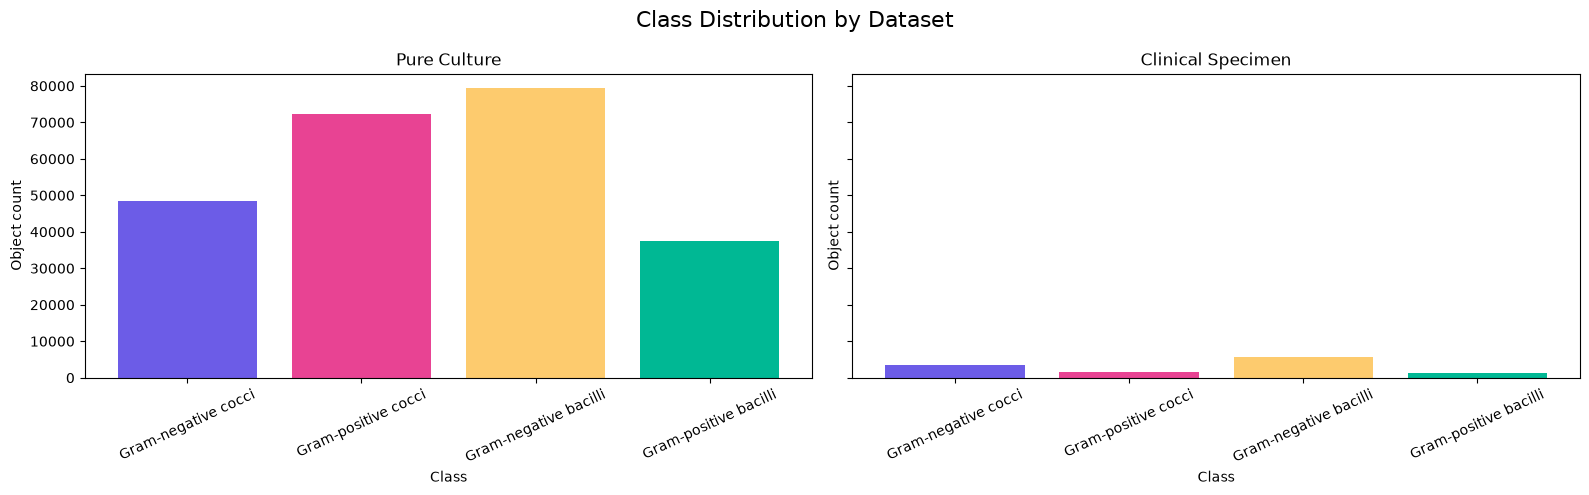

In [12]:
CLASS_COLORS = {
    0: "#6C5CE7",  # Purple
    1: "#E84393",  # Pink
    2: "#FDCB6E",  # Yellow
    3: "#00B894",  # Teal
}

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, dataset_name in zip(axes, ["Pure Culture", "Clinical Specimen"]):
    subset = class_dist_df[class_dist_df["dataset"] == dataset_name]
    colors = [CLASS_COLORS[class_id] for class_id in subset["class_id"]]
    ax.bar(subset["class_name"], subset["count"], color=colors)
    ax.set_title(dataset_name)
    ax.set_xlabel("Class")
    ax.set_ylabel("Object count")
    ax.tick_params(axis="x", rotation=25)

fig.suptitle("Class Distribution by Dataset", fontsize=16)
fig.tight_layout()
plt.show()

## 3. Dataset Samples

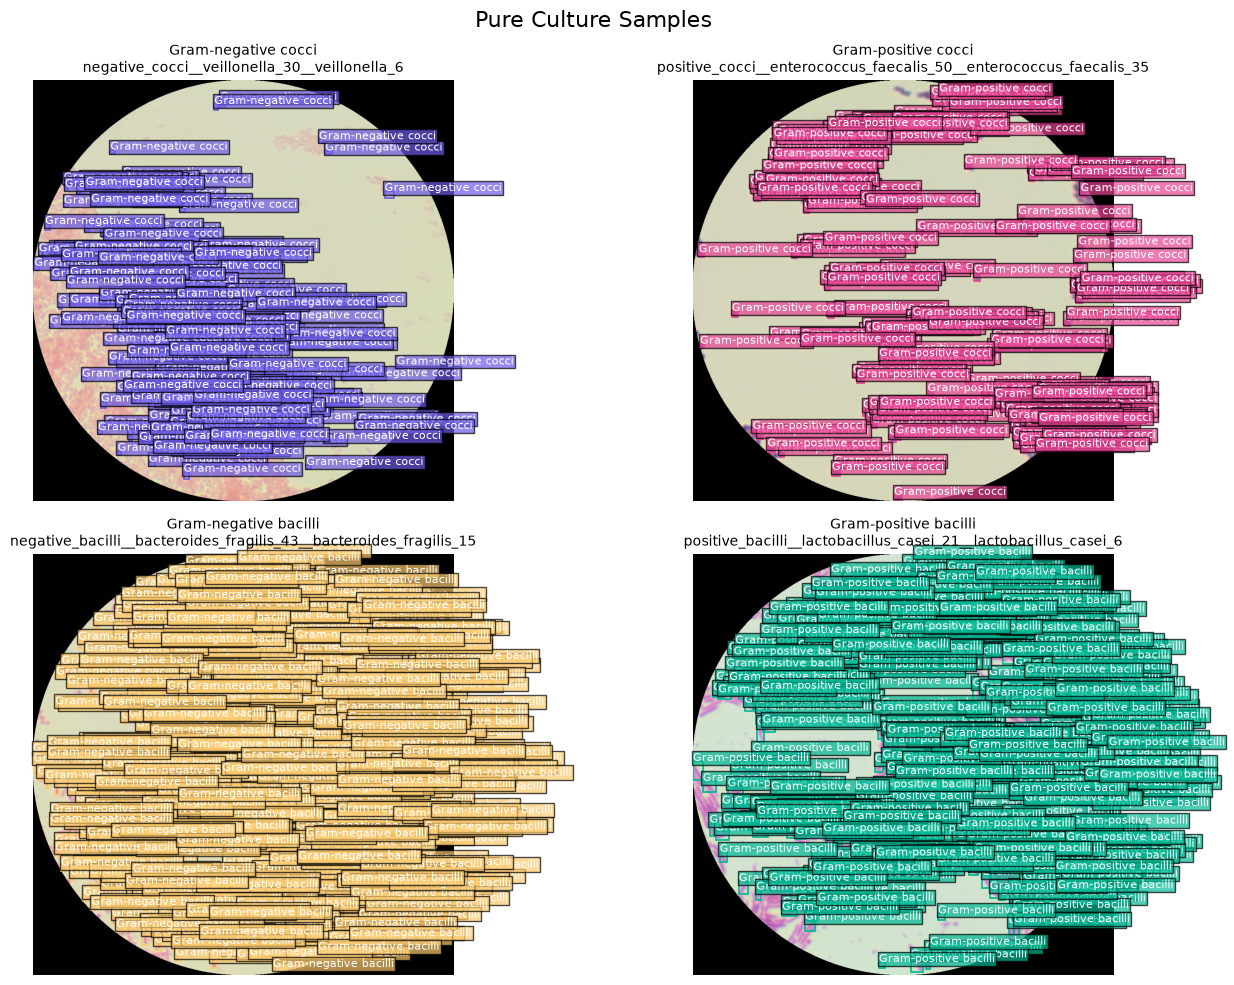

In [13]:
plot_class_samples(images_df, boxes_df, dataset_name="Pure Culture")

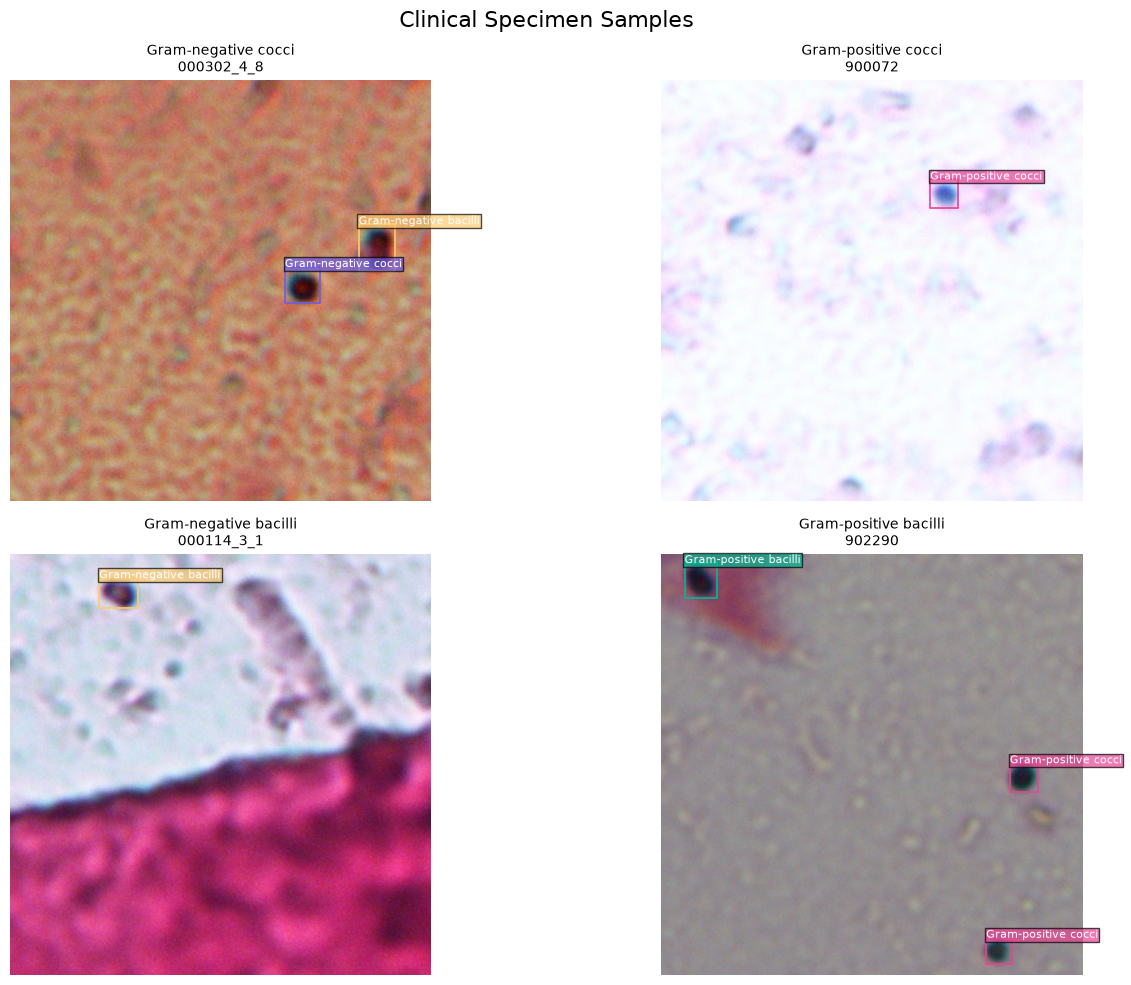

In [14]:
plot_class_samples(images_df, boxes_df, dataset_name="Clinical Specimen")

## 4. Bounding Box Analysis

In [15]:
bbox_summary = (
    boxes_df.groupby("dataset", as_index=False)
    .agg(
        mean_width_norm=("width_norm", "mean"),
        mean_height_norm=("height_norm", "mean"),
        mean_area_norm=("area_norm", "mean"),
        median_area_norm=("area_norm", "median"),
        mean_bbox_area_px=("bbox_area_px", "mean"),
    )
)
bbox_summary = bbox_summary.round(6)
bbox_summary

,dataset,mean_width_norm,mean_height_norm,mean_area_norm,median_area_norm,mean_bbox_area_px
0,Clinical Specimen,0.084358,0.083861,0.007203,0.006626,2950.146375
1,Pure Culture,0.015377,0.015557,0.000276,0.000178,336.035900


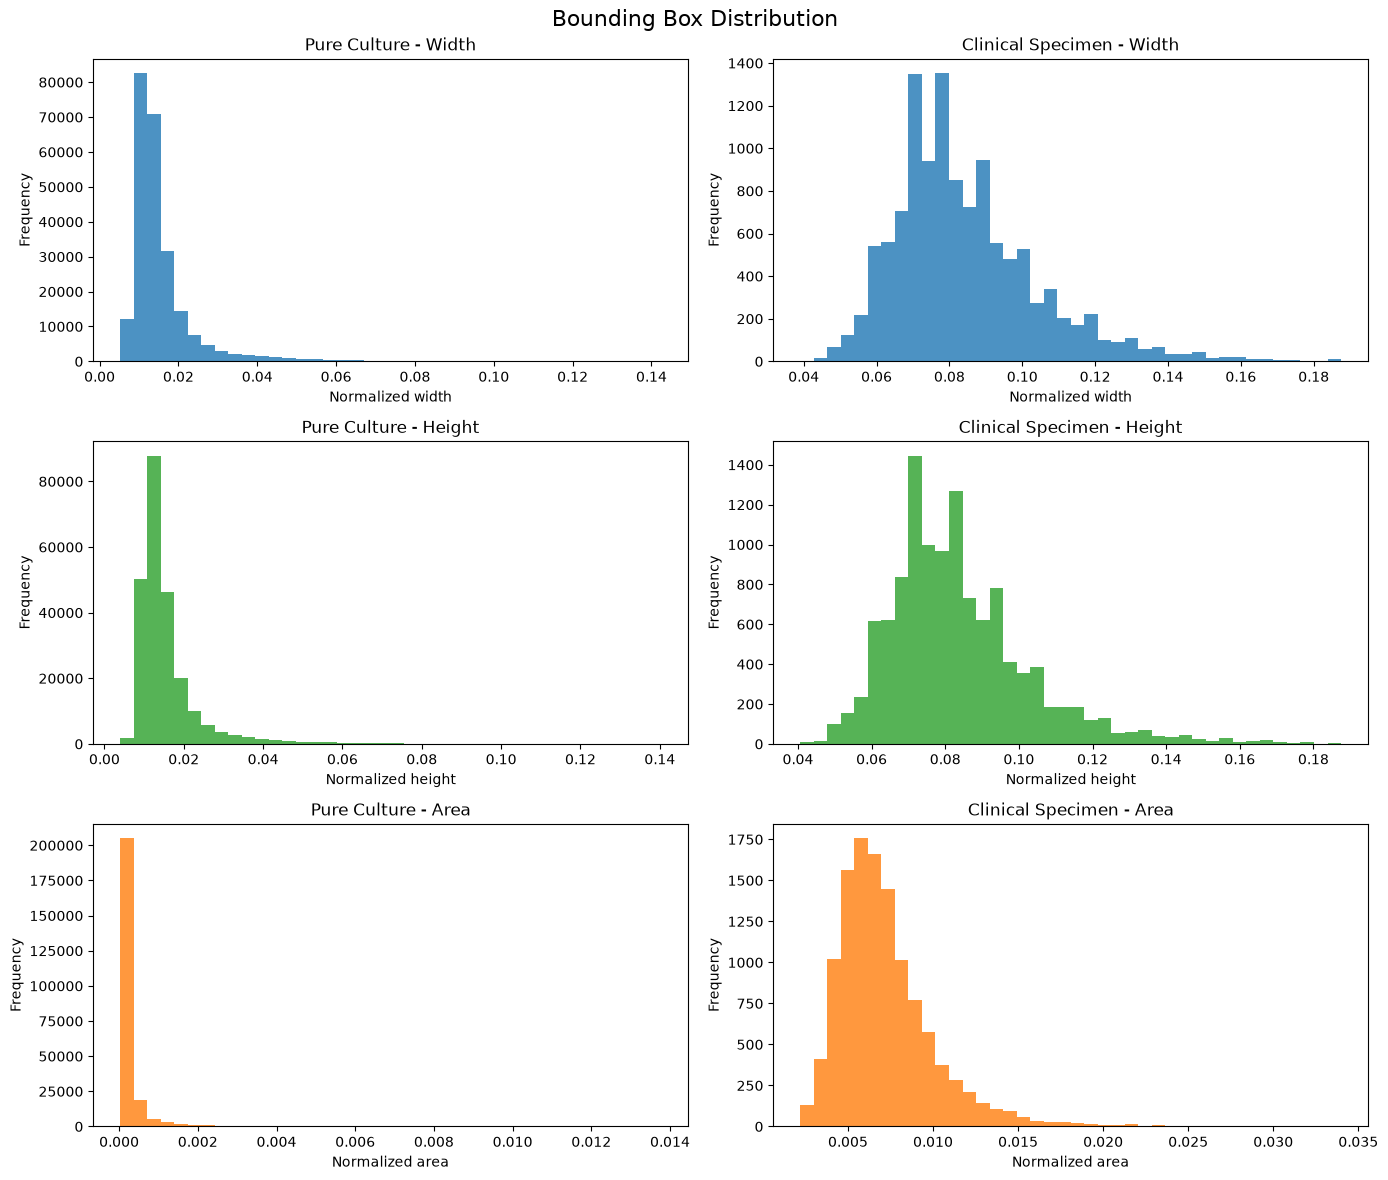

In [16]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
datasets = ["Pure Culture", "Clinical Specimen"]

for col, dataset_name in enumerate(datasets):
    subset = boxes_df[boxes_df["dataset"] == dataset_name]
    axes[0, col].hist(subset["width_norm"], bins=40, color="tab:blue", alpha=0.8)
    axes[0, col].set_title(f"{dataset_name} - Width")
    axes[0, col].set_xlabel("Normalized width")

    axes[1, col].hist(subset["height_norm"], bins=40, color="tab:green", alpha=0.8)
    axes[1, col].set_title(f"{dataset_name} - Height")
    axes[1, col].set_xlabel("Normalized height")

    axes[2, col].hist(subset["area_norm"], bins=40, color="tab:orange", alpha=0.8)
    axes[2, col].set_title(f"{dataset_name} - Area")
    axes[2, col].set_xlabel("Normalized area")

for ax in axes.ravel():
    ax.set_ylabel("Frequency")

fig.suptitle("Bounding Box Distribution", fontsize=16)
fig.tight_layout()
plt.show()

## 5. Objects Per Image Analysis

In [17]:
objects_per_image_summary = (
    images_df.groupby("dataset", as_index=False)
    .agg(
        mean_objects=("num_objects", "mean"),
        median_objects=("num_objects", "median"),
        max_objects=("num_objects", "max"),
        min_objects=("num_objects", "min"),
    )
)
objects_per_image_summary = objects_per_image_summary.round(2)
objects_per_image_summary

,dataset,mean_objects,median_objects,max_objects,min_objects
0,Clinical Specimen,1.97,1.0,17,1
1,Pure Culture,437.96,395.5,1500,33


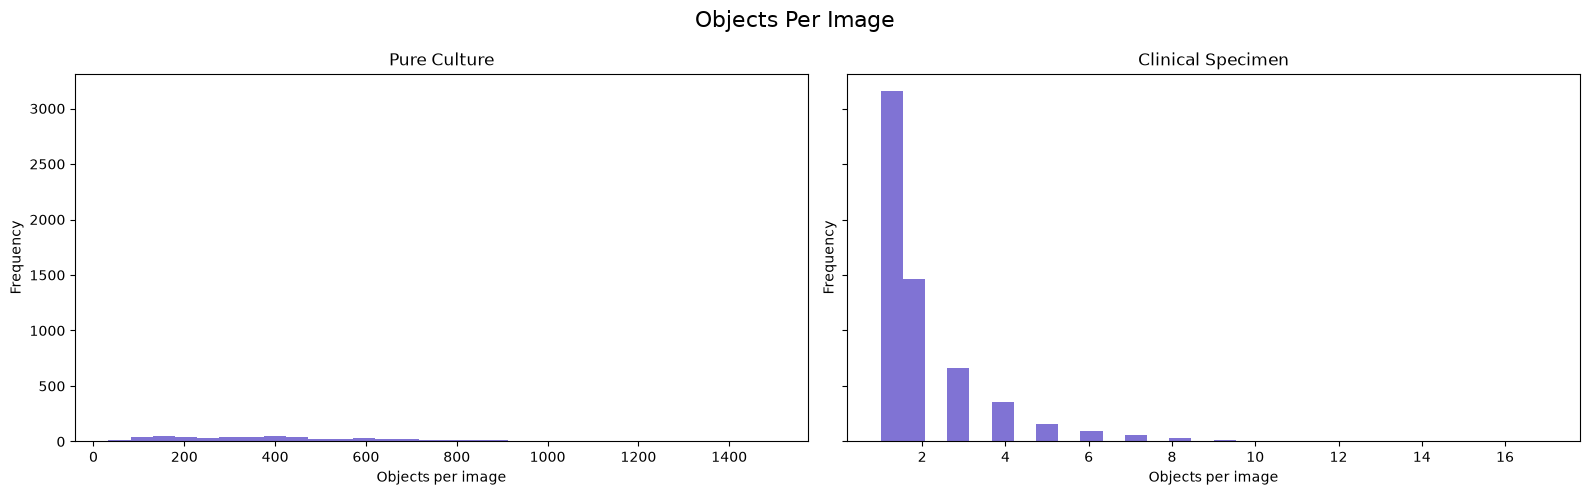

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, dataset_name in zip(axes, ["Pure Culture", "Clinical Specimen"]):
    subset = images_df[images_df["dataset"] == dataset_name]
    ax.hist(subset["num_objects"], bins=30, color="slateblue", alpha=0.85)
    ax.set_title(dataset_name)
    ax.set_xlabel("Objects per image")
    ax.set_ylabel("Frequency")

fig.suptitle("Objects Per Image", fontsize=16)
fig.tight_layout()
plt.show()

## 6. Pure Culture vs Clinical Specimen Comparison

In [19]:
comparison_table = overview_table.merge(
    objects_per_image_summary,
    on="dataset",
    how="left",
).merge(
    bbox_summary[["dataset", "mean_bbox_area_px", "mean_area_norm"]],
    on="dataset",
    how="left",
)

comparison_table = comparison_table[[
    "dataset",
    "images",
    "objects",
    "mean_objects",
    "median_objects",
    "max_objects",
    "mean_bbox_area_px",
    "mean_area_norm",
    "dataset_size",
    "label_type",
]]

comparison_table = comparison_table.round({
    "mean_objects": 2,
    "median_objects": 2,
    "mean_bbox_area_px": 2,
    "mean_area_norm": 6,
})

comparison_table

,dataset,images,objects,mean_objects,median_objects,max_objects,mean_bbox_area_px,mean_area_norm,dataset_size,label_type
0,Clinical Specimen,6005,11824,1.97,1.0,17,2950.15,0.007203,595.27 MB,Manual label
1,Pure Culture,542,237376,437.96,395.5,1500,336.04,0.000276,873.27 MB,Pseudo-label


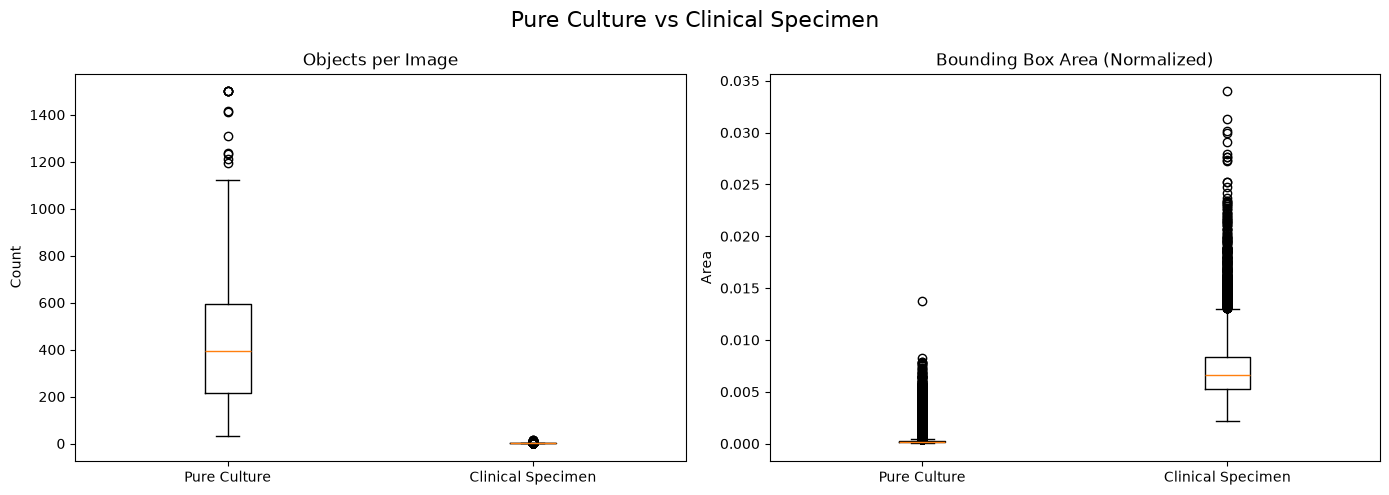

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

datasets = ["Pure Culture", "Clinical Specimen"]

data_objects = [
    images_df.loc[images_df["dataset"] == dataset, "num_objects"].dropna()
    for dataset in datasets
]

data_areas = [
    boxes_df.loc[boxes_df["dataset"] == dataset, "area_norm"].dropna()
    for dataset in datasets
]

axes[0].boxplot(
    data_objects,
    tick_labels=datasets
)
axes[0].set_title("Objects per Image")
axes[0].set_ylabel("Count")

axes[1].boxplot(
    data_areas,
    tick_labels=datasets
)
axes[1].set_title("Bounding Box Area (Normalized)")
axes[1].set_ylabel("Area")

fig.suptitle("Pure Culture vs Clinical Specimen", fontsize=16)
fig.tight_layout()
plt.show()